# 01 Source exploration

**Purpose.** Validate the *real* authoritative source samples retrieved by the `syte-pipeline` package: inspect their actual structure, CRS, geometry types and
address-related fields, and record what is confirmed vs. still unknown before any
business logic is written.

This notebook is a **validation workbench**. It imports production functions and
reads production artifacts. It contains no downloader, parsing, property, or metric
logic of its own.

> Run `syte-pipeline inspect --config configs/bremer_platz.yaml` at least once
> before executing this notebook, so the raw artifacts and manifests exist.

## 2. Imports and repository-root discovery

In [1]:
import json
from pathlib import Path
from dataclasses import asdict

import pandas as pd

from syte_pipeline import __version__
from syte_pipeline.config import load_config
from syte_pipeline.download import DownloadResult, MANIFEST_NAME
from syte_pipeline.inspect import inspect_artifact

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').is_file():
            return candidate
    raise FileNotFoundError('Could not locate repository root (pyproject.toml).')

import os
REPO_ROOT = find_repo_root(Path.cwd())
# Work from the repository root so config-relative paths resolve the same way
# they do for the CLI.
os.chdir(REPO_ROOT)
print('syte_pipeline version:', __version__)
print('repository root:', REPO_ROOT)

syte_pipeline version: 0.1.0
repository root: /Users/arthur/Documents/Projects/syte_coding_challenge


## 3. Load configuration

In [2]:
CONFIG_PATH = REPO_ROOT / 'configs' / 'bremer_platz.yaml'
config = load_config(CONFIG_PATH)
print('config:', config.config_path)
print('raw dir:', config.raw_dir)
print('timeout (s):', config.request_timeout_seconds, '| use_cache:', config.use_cache)

config: /Users/arthur/Documents/Projects/syte_coding_challenge/configs/bremer_platz.yaml
raw dir: data/raw
timeout (s): 60.0 | use_cache: True


## 4. Target addresses

In [3]:
addresses_df = pd.DataFrame(
    [(a.street, a.house_number, a.postcode, a.city) for a in config.addresses],
    columns=['street', 'house_number', 'postcode', 'city'],
)
addresses_df

,street,house_number,postcode,city
0,Bremer Platz,50,48155,Münster
1,Bremer Platz,52,48155,Münster
2,Bremer Platz,54,48155,Münster


## 5. Configured sources

In [4]:
sources_df = pd.DataFrame(
    [(s.name, s.enabled, s.expected_format, s.url) for s in config.sources],
    columns=['name', 'enabled', 'expected_format', 'url'],
)
sources_df

,name,enabled,expected_format,url
0,alkis_flurstuecke,True,gml,https://www.wfs.nrw.de/geobasis/wfs_nw_alkis_v...
1,alkis_gebaeude,True,gml,https://www.wfs.nrw.de/geobasis/wfs_nw_alkis_v...
2,lod2_gebaeudemodell,False,citygml,https://www.opengeodata.nrw.de/produkte/geobas...


## 6. Raw artifact inventory

Scan `data/raw/<source>/manifest.json` and rebuild `DownloadResult` objects from
the manifests written by the production downloader.

In [5]:
def load_download_results(cfg) -> dict:
    results = {}
    for source in cfg.sources:
        manifest_path = cfg.raw_dir / source.name / MANIFEST_NAME
        if not manifest_path.is_file():
            continue
        with manifest_path.open('r', encoding='utf-8') as fh:
            m = json.load(fh)
        results[source.name] = DownloadResult(
            source_name=m['source_name'],
            url=m.get('source_url', ''),
            local_path=m['local_path'],
            manifest_path=str(manifest_path),
            sha256=m.get('sha256', ''),
            reused=m.get('reused', False),
            retrieved_at=m.get('retrieved_at_utc', ''),
            expected_format=m.get('expected_format'),
            http_status=m.get('http_status'),
            content_type=m.get('content_type'),
            content_length=m.get('content_length'),
        )
    return results

downloads = load_download_results(config)
if not downloads:
    print('No manifests found. Run the inspect command first.')
inventory_df = pd.DataFrame(
    [(n, d.local_path, d.content_length, d.content_type) for n, d in downloads.items()],
    columns=['source', 'local_path', 'bytes', 'content_type'],
)
inventory_df

,source,local_path,bytes,content_type
0,alkis_flurstuecke,data/raw/alkis_flurstuecke/alkis_flurstuecke.gml,99105,application/gml+xml; version=3.2.1; charset=utf-8
1,alkis_gebaeude,data/raw/alkis_gebaeude/alkis_gebaeude.gml,52984,application/gml+xml; version=3.2.1; charset=utf-8


## 7. Manifest details

In [6]:
manifest_df = pd.DataFrame([asdict(d) for d in downloads.values()])
manifest_df

,source_name,url,local_path,manifest_path,sha256,reused,retrieved_at,expected_format,http_status,content_type,content_length
0,alkis_flurstuecke,https://www.wfs.nrw.de/geobasis/wfs_nw_alkis_v...,data/raw/alkis_flurstuecke/alkis_flurstuecke.gml,data/raw/alkis_flurstuecke/manifest.json,84b1ce3d6c6c87a7e2a1a3f6169fab7c5e032780d1e987...,False,2026-08-07T17:24:49.683169+00:00,gml,200,application/gml+xml; version=3.2.1; charset=utf-8,99105
1,alkis_gebaeude,https://www.wfs.nrw.de/geobasis/wfs_nw_alkis_v...,data/raw/alkis_gebaeude/alkis_gebaeude.gml,data/raw/alkis_gebaeude/manifest.json,795464721fe158f434d86c954e377b4a4871d2d2bd7d27...,False,2026-08-07T17:24:51.137260+00:00,gml,200,application/gml+xml; version=3.2.1; charset=utf-8,52984


## 8. Actual source schemas

Run the production `inspect_artifact` on each downloaded artifact.

In [7]:
inspections = {name: inspect_artifact(d) for name, d in downloads.items()}
schema_rows = []
for name, insp in inspections.items():
    schema_rows.append((name, insp.kind, insp.detected_format,
                        insp.feature_count or insp.row_count, len(insp.columns)))
schema_df = pd.DataFrame(schema_rows,
    columns=['source', 'kind', 'format', 'rows/features', 'n_columns'])
schema_df

/opt/miniconda3/envs/syte-property-pipeline/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: Field with same name (identifier) already exists in (Flurstueck). Skipping newer ones
  return ogr_read(
/opt/miniconda3/envs/syte-property-pipeline/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: Field with same name (identifier) already exists in (GebaeudeBauwerk). Skipping newer ones
  return ogr_read(


,source,kind,format,rows/features,n_columns
0,alkis_flurstuecke,geospatial,gml,50,23
1,alkis_gebaeude,geospatial,gml,50,11


In [8]:
for name, insp in inspections.items():
    print(f'=== {name} ({insp.kind}) ===')
    if insp.note:
        print('note:', insp.note)
    for col in insp.columns:
        print(f'  {col}: dtype={insp.dtypes.get(col)} nulls={insp.null_counts.get(col)}')
    print()

=== alkis_flurstuecke (geospatial) ===
  gml_id: dtype=str nulls=0
  identifier: dtype=str nulls=0
  idflurst: dtype=str nulls=0
  flstkennz: dtype=str nulls=0
  land: dtype=str nulls=0
  landschl: dtype=str nulls=0
  gemarkung: dtype=str nulls=0
  gemaschl: dtype=str nulls=0
  flur: dtype=int32 nulls=0
  flurschl: dtype=str nulls=0
  flstnrzae: dtype=int32 nulls=0
  regbezirk: dtype=str nulls=0
  regbezschl: dtype=str nulls=0
  kreis: dtype=str nulls=0
  kreisschl: dtype=str nulls=0
  gemeinde: dtype=str nulls=0
  gmdschl: dtype=str nulls=0
  oid: dtype=str nulls=0
  aktualit: dtype=str nulls=0
  flaeche: dtype=float64 nulls=0
  abwrecht: dtype=str nulls=0
  lagebeztxt: dtype=str nulls=0
  tntxt: dtype=str nulls=0

=== alkis_gebaeude (geospatial) ===
  gml_id: dtype=str nulls=0
  identifier: dtype=str nulls=0
  oid: dtype=str nulls=0
  aktualit: dtype=str nulls=0
  gebnutzbez: dtype=str nulls=0
  funktion: dtype=str nulls=0
  gfkzshh: dtype=str nulls=5
  gmdschl: dtype=str nulls=0
  r

## 9. Address-related fields and sample values

In [9]:
for name, insp in inspections.items():
    print(f'=== {name} ===')
    if insp.address_fields:
        for col in insp.address_fields:
            print(f'  {col}: {insp.sample_values.get(col, [])}')
    else:
        print('  no address-related fields detected')
    print()

=== alkis_flurstuecke ===
  lagebeztxt: ['Mendener Str. 117', 'Mendener Str.', 'Mendener Str.']

=== alkis_gebaeude ===
  rellage: ['Unter der Erdoberfläche']
  lagebeztxt: ['Mendener Str. 104', 'August-Thyssen-Str. 57', 'Mendener Str. 100']



## 10. Geospatial diagnostics

In [10]:
geo_rows = []
for name, insp in inspections.items():
    if insp.kind == 'geospatial':
        geo_rows.append((name, insp.crs, insp.geometry_column,
                         ', '.join(insp.geometry_types),
                         insp.null_geometries, insp.empty_geometries,
                         insp.invalid_geometries))
geo_df = pd.DataFrame(geo_rows,
    columns=['source', 'crs', 'geom_col', 'geom_types',
             'null_geom', 'empty_geom', 'invalid_geom'])
geo_df

,source,crs,geom_col,geom_types,null_geom,empty_geom,invalid_geom
0,alkis_flurstuecke,EPSG:25832,geometry,MultiPolygon,0,0,0
1,alkis_gebaeude,EPSG:25832,geometry,MultiPolygon,0,0,0


## 11. Plot every readable geospatial source (in its source CRS)

Each source is plotted separately, without reprojection.

/opt/miniconda3/envs/syte-property-pipeline/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: Field with same name (identifier) already exists in (Flurstueck). Skipping newer ones
  return ogr_read(


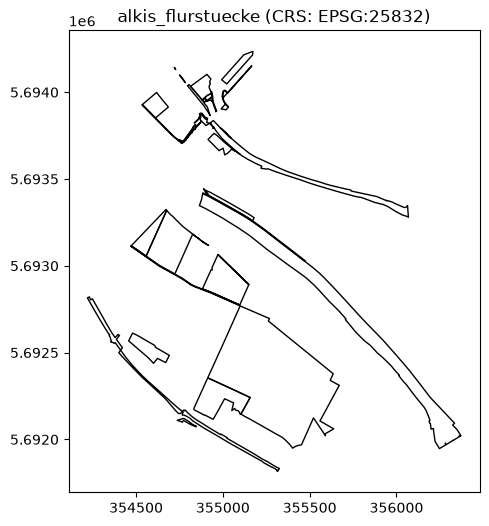

/opt/miniconda3/envs/syte-property-pipeline/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: Field with same name (identifier) already exists in (GebaeudeBauwerk). Skipping newer ones
  return ogr_read(


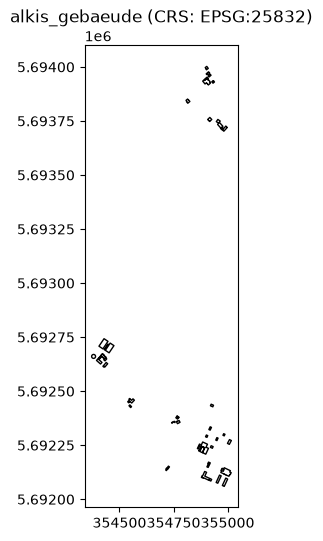

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt

for name, insp in inspections.items():
    if insp.kind != 'geospatial':
        continue
    path = Path(insp.local_path)
    if not path.is_absolute():
        path = REPO_ROOT / path
    gdf = gpd.read_file(path)
    ax = gdf.plot(figsize=(6, 6), edgecolor='black', facecolor='none')
    ax.set_title(f'{name} (CRS: {gdf.crs})')
    ax.set_aspect('equal')
    plt.show()

## 12. Source-capability matrix

In [12]:
matrix_rows = []
for src in config.sources:
    d = downloads.get(src.name)
    insp = inspections.get(src.name)
    matrix_rows.append((
        src.name,
        'yes' if d else ('disabled' if not src.enabled else 'no'),
        'yes' if insp and insp.kind in {'tabular', 'geospatial'} else 'no',
        'yes' if insp and insp.kind == 'geospatial' else 'no',
        'yes' if insp and insp.crs else 'no',
        'yes' if insp and insp.address_fields else 'no',
    ))
capability_df = pd.DataFrame(matrix_rows,
    columns=['source', 'retrieved', 'readable', 'geospatial', 'crs', 'address_field'])
capability_df

,source,retrieved,readable,geospatial,crs,address_field
0,alkis_flurstuecke,yes,yes,yes,yes,yes
1,alkis_gebaeude,yes,yes,yes,yes,yes
2,lod2_gebaeudemodell,disabled,no,no,no,no


## 13. Open questions

In [13]:
open_questions = [
    'How are the three target addresses resolved to specific cadastral parcels?',
    'Which field carries the authoritative address string, and how reliable is it?',
    'How should the LoD2 CityGML model be read and joined for floor / BGF / GFZ metrics?',
    'What spatial filter (bbox) replaces the bounded count-limited sample once addresses are geocoded?',
]
for q in open_questions:
    print('-', q)

- How are the three target addresses resolved to specific cadastral parcels?
- Which field carries the authoritative address string, and how reliable is it?
- How should the LoD2 CityGML model be read and joined for floor / BGF / GFZ metrics?
- What spatial filter (bbox) replaces the bounded count-limited sample once addresses are geocoded?


## 14. Confirmed facts, invalidated assumptions, readiness for Milestone 2

**Confirmed (observed from real samples):**

- The NRW ALKIS simplified WFS is reachable and serves parcels (`Flurstueck`) and
  building footprints (`GebaeudeBauwerk`).
- Both are delivered as GML, read by GeoPandas as **EPSG:25832** `MultiPolygon`
  geometry (the GML `MultiSurface` is normalised to `MultiPolygon` on read).
- Parcels expose `lagebeztxt` (free-text Lagebezeichnung, e.g. 'Mendener Str. 117').
- Building footprints expose `lagebeztxt` and `rellage` (relative location, e.g.
  'Unter der Erdoberfläche') in the retrieved sample.

**Invalidated / corrected assumptions:**

- The WFS does **not** offer JSON/GeoJSON output; GML (and GeoPackage / Shapefile) are
  the real formats. Any imagined GeoJSON schema would have been wrong.
- The `lagebeztxt` string is free-text and not guaranteed to contain a house number for
  every feature, so address matching is not a trivial string equality.

**Readiness for Milestone 2:**

- Real field names, CRS and geometry types are now known, so parcel/address resolution
  can be designed against the *actual* schema rather than an imagined one.
- The LoD2 CityGML reading strategy remains an open question to resolve before floor /
  BGF / GFZ work.